In [1]:
## import dependencies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Fish.csv to Fish.csv


In [3]:
df = pd.read_csv('Fish.csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [4]:
## goal is to model the weight of the fishes according to the other features

In [5]:
df.shape

(159, 7)

In [6]:
df.isna().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [8]:
## statistics of the dataset

df.describe(include="all")

,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500


## Outlier analysis

In [9]:
## an outlier is a data point that is outside mean(X) - 3 * std(X), mean(X) + 3 *std(X) (assuming the underlying Normal distribution)

## I will use the definition of an outlier as a point outside of the interquantile range
## x < Q1 - 1.5 (Q3-Q1) or x > Q3 + 1.5 (Q3-Q1)

## numerical features of the dataset
numerical_data = df.select_dtypes(include='number')
numerical_data

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936
155,13.4,11.7,12.4,13.5,2.4300,1.2690
156,12.2,12.1,13.0,13.8,2.2770,1.2558
157,19.7,13.2,14.3,15.2,2.8728,2.0672


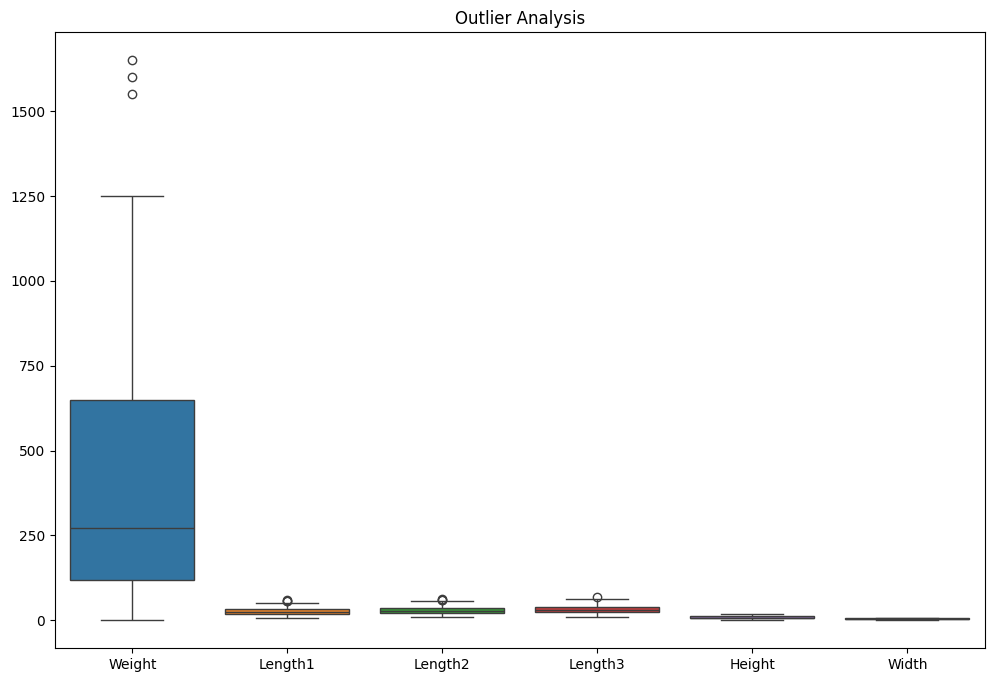

In [10]:
plt.figure(figsize =(12,8))
sns.boxplot(data = numerical_data )
plt.title("Outlier Analysis")
plt.show()

In [12]:
numerical_data

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936
155,13.4,11.7,12.4,13.5,2.4300,1.2690
156,12.2,12.1,13.0,13.8,2.2770,1.2558
157,19.7,13.2,14.3,15.2,2.8728,2.0672


In [13]:
Q1 = numerical_data.quantile(0.25)
Q3 = numerical_data.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = numerical_data[(numerical_data < lower_limit) | (numerical_data > upper_limit)]
data_without_outliers = numerical_data[(numerical_data >= lower_limit) & (numerical_data <= upper_limit)]

In [17]:
data_without_outliers.isna().sum()

,0
Weight,3
Length1,3
Length2,3
Length3,1
Height,0
Width,0


In [21]:
## when we remove the outliers we get nan values that we will input with the mean of the distribution (per feature)
filtered_df = pd.concat([data_without_outliers, df["Species"]],axis=1)
filtered_df

,Weight,Length1,Length2,Length3,Height,Width,Species
0,242.0,23.2,25.4,30.0,11.5200,4.0200,Bream
1,290.0,24.0,26.3,31.2,12.4800,4.3056,Bream
2,340.0,23.9,26.5,31.1,12.3778,4.6961,Bream
3,363.0,26.3,29.0,33.5,12.7300,4.4555,Bream
4,430.0,26.5,29.0,34.0,12.4440,5.1340,Bream
...,...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936,Smelt
155,13.4,11.7,12.4,13.5,2.4300,1.2690,Smelt
156,12.2,12.1,13.0,13.8,2.2770,1.2558,Smelt
157,19.7,13.2,14.3,15.2,2.8728,2.0672,Smelt


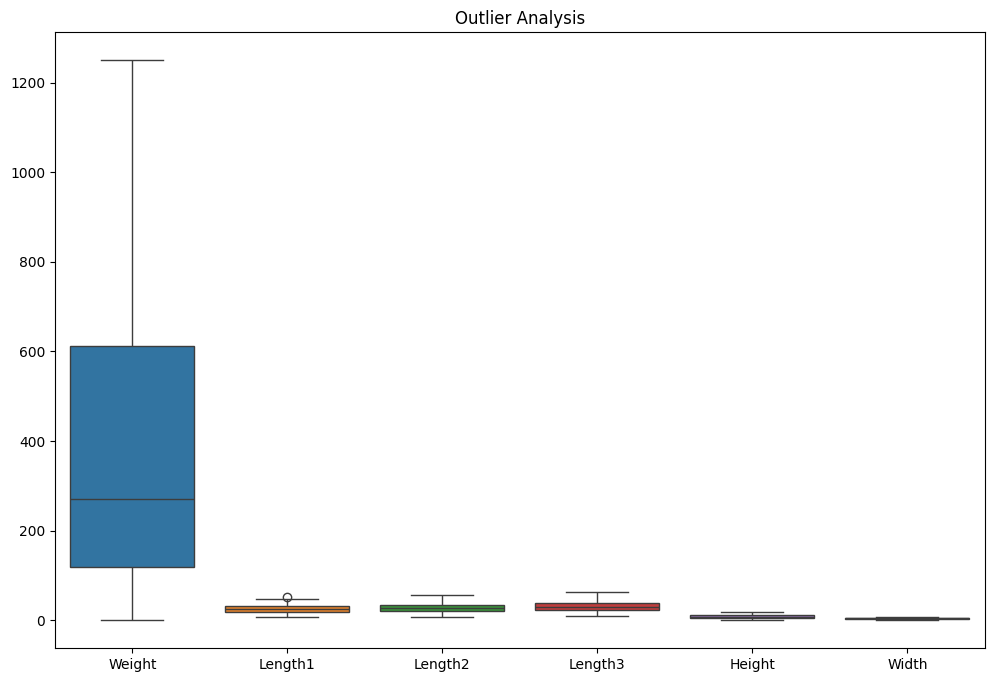

In [22]:
plt.figure(figsize =(12,8))
sns.boxplot(data =  filtered_df.select_dtypes(include='number') )
plt.title("Outlier Analysis")
plt.show()

In [27]:
df = filtered_df
df.isna().sum() ## these are the outliers that were transformed into nans



,0
Weight,3
Length1,3
Length2,3
Length3,1
Height,0
Width,0
Species,0


In [9]:
## steps for our modelling project

# 0. clean the data if needed (in this case since they are all measurements then we should ensure that the data is all positive)
# if there are too much of correlated features (corr > 0.95 we throw them out)
# 1. target variable and the explanatory variables
# 2. we must dummify the categorical variable
# 3. train test split
# 4. imputer of strategy and standardize the variables --> standard scaler
# 5. model.fit(X_train, y_train)
# 6. calculate the predictions
# 7. evaluate the performances on the train set and on the test set (r2 score closer of 1 saves the day)

In [10]:
df[df.duplicated()]

,Species,Weight,Length1,Length2,Length3,Height,Width


In [28]:
## EDA of the numerical features

numerical_data = df.select_dtypes(include='number')
numerical_data

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936
155,13.4,11.7,12.4,13.5,2.4300,1.2690
156,12.2,12.1,13.0,13.8,2.2770,1.2558
157,19.7,13.2,14.3,15.2,2.8728,2.0672


/tmp/ipython-input-3352307791.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(numerical_data.Weight, kde= True)


<Axes: xlabel='Weight', ylabel='Density'>

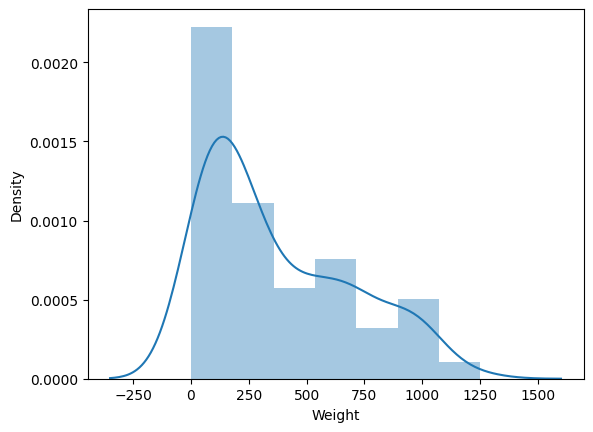

In [29]:
sns.distplot(numerical_data.Weight, kde= True)

In [30]:
for column in numerical_data.columns:
  print(column)

Weight
Length1
Length2
Length3
Height
Width


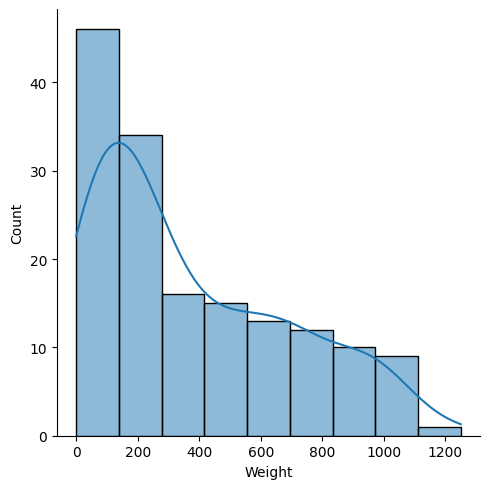

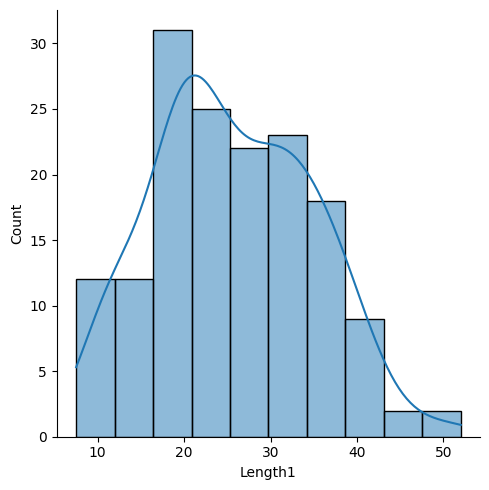

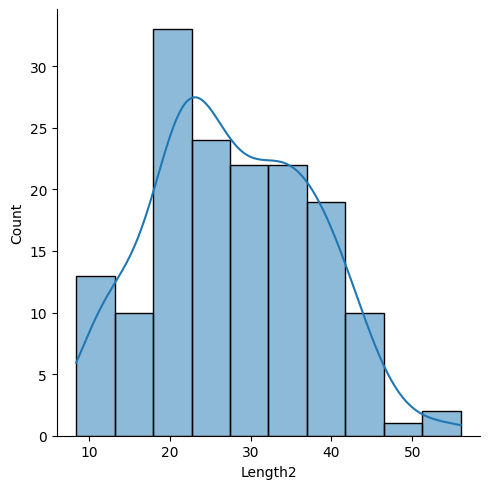

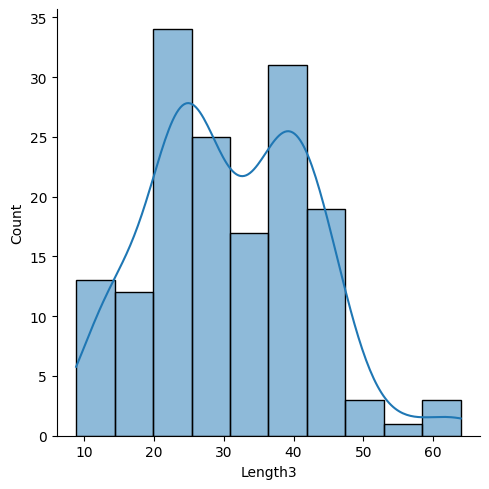

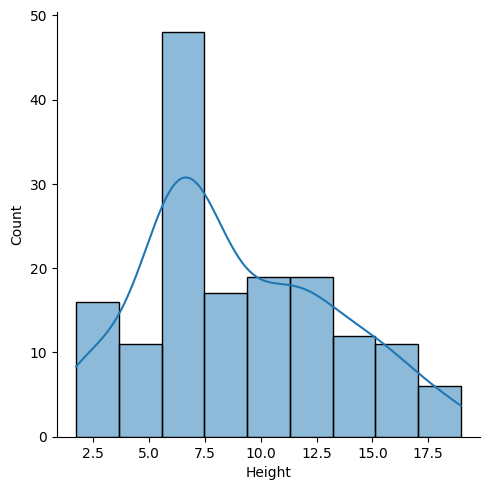

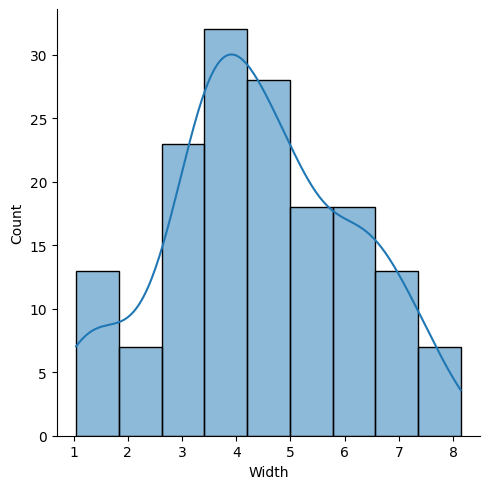

In [31]:
for column in numerical_data.columns:
  sns.displot(numerical_data[column], kde=True)

In [32]:
## distribution Species

fig = px.bar(df, x="Species", y= "Weight")
fig.show()

In [33]:
median_df = df.groupby("Species")["Weight"].median()
pd.DataFrame(median_df)


,Weight
Species,
Bream,610.00
Parkki,145.00
Perch,207.50
Pike,478.00
Roach,147.50
Smelt,9.85
Whitefish,423.00


<Axes: xlabel='Species', ylabel='Weight'>

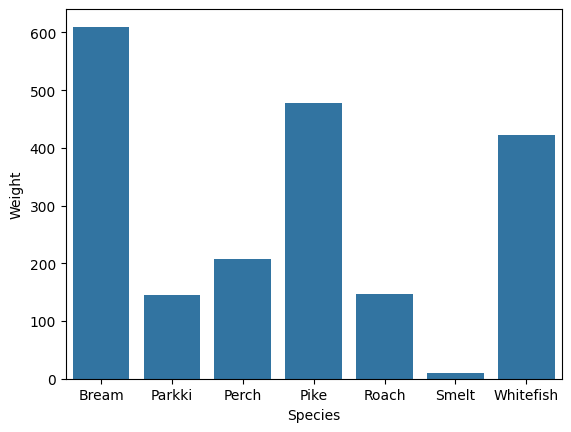

In [34]:
median_df = df.groupby("Species")["Weight"].median()

sns.barplot(x= "Species", y = "Weight", data = pd.DataFrame(median_df), errorbar = ("ci", 95))

In [35]:
# violin plot

fig = px.violin(df, x="Species", y= "Weight")
fig.show()

In [36]:
fig = px.box(df, x="Species", y= "Weight")
fig.show()

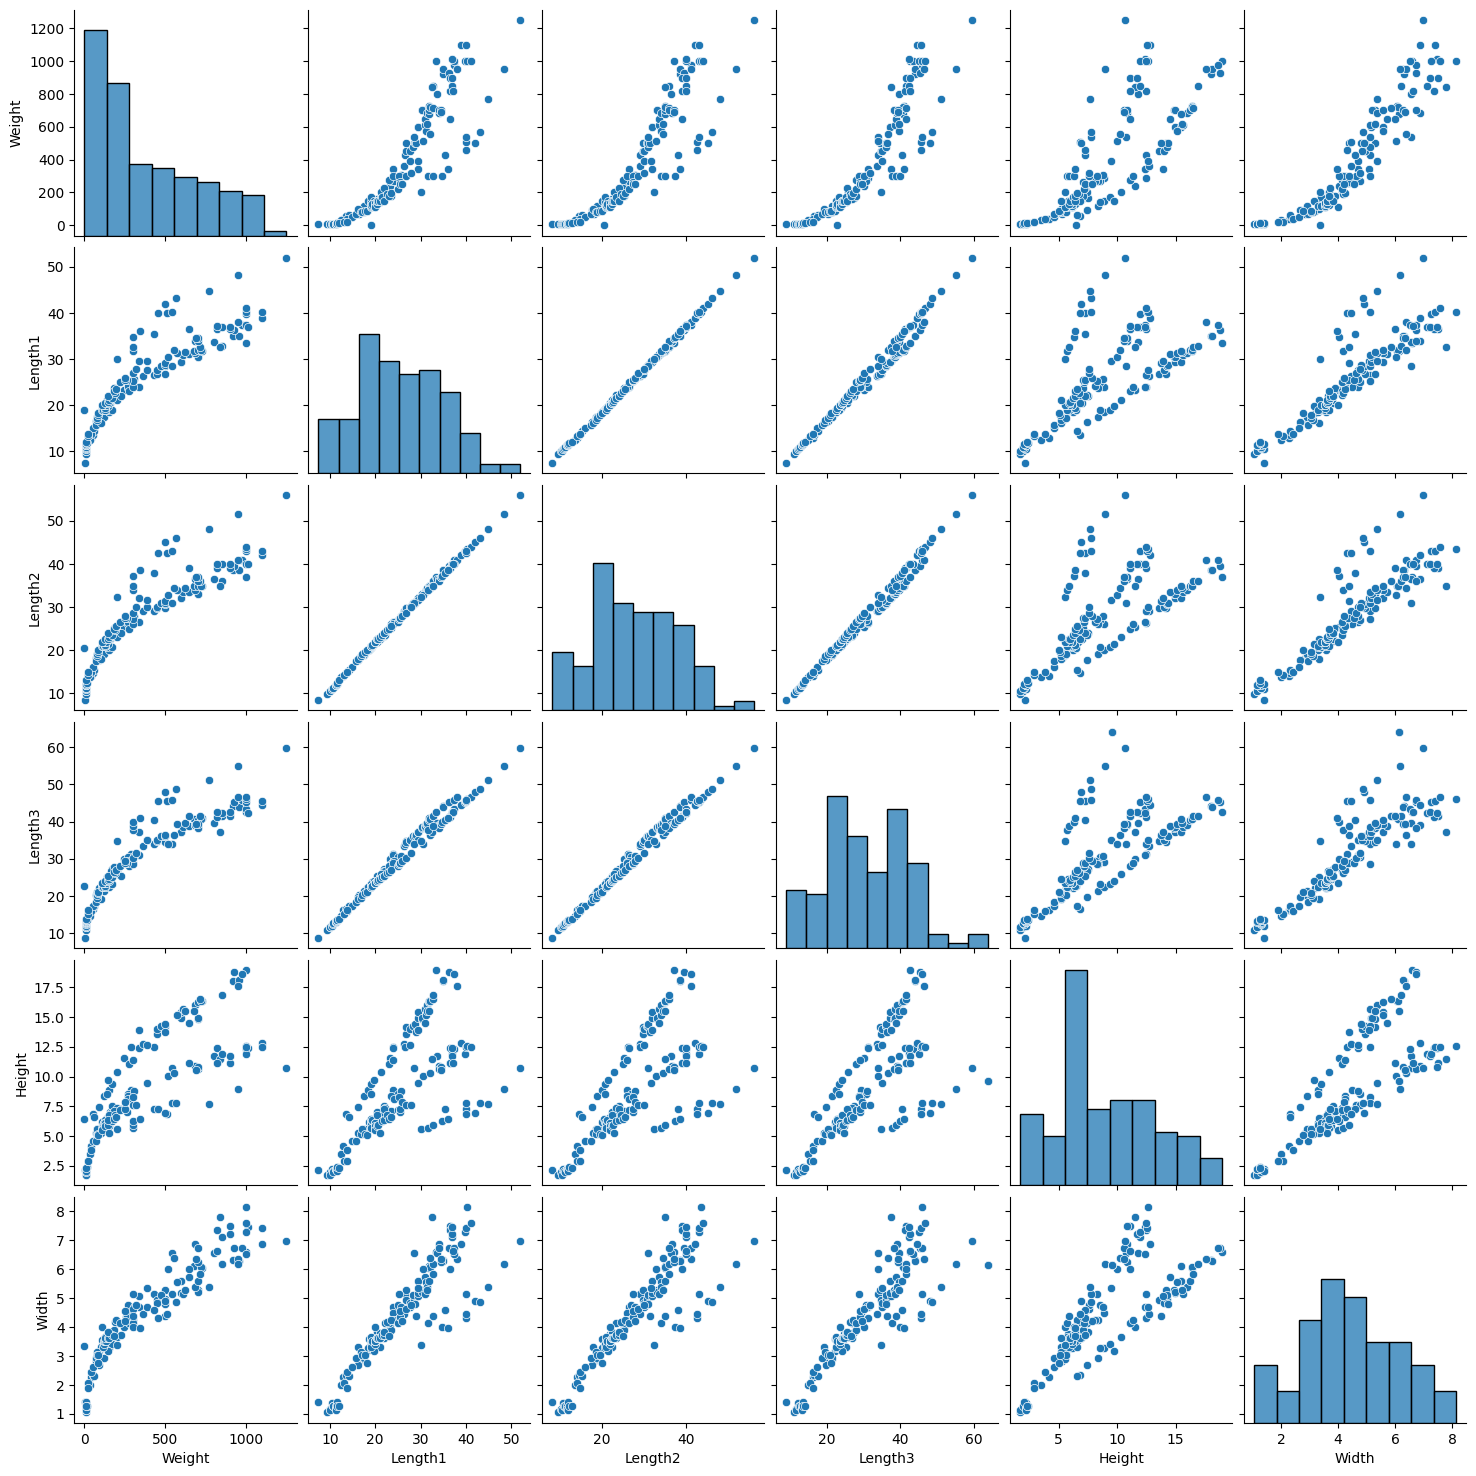

In [37]:
sns.pairplot(df)

In [38]:
numerical_data.corr()

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.895743,0.899759,0.907292,0.801871,0.923432
Length1,0.895743,1.000000,0.999418,0.990612,0.676326,0.889166
Length2,0.899759,0.999418,1.000000,0.993049,0.691954,0.895584
Length3,0.907292,0.990612,0.993049,1.000000,0.718485,0.879421
Height,0.801871,0.676326,0.691954,0.718485,1.000000,0.792881
Width,0.923432,0.889166,0.895584,0.879421,0.792881,1.000000


In [39]:
df = df.drop(columns=["Length2", "Length3"]) ## feature selection: we dropped two highly correlated features
df

,Weight,Length1,Height,Width,Species
0,242.0,23.2,11.5200,4.0200,Bream
1,290.0,24.0,12.4800,4.3056,Bream
2,340.0,23.9,12.3778,4.6961,Bream
3,363.0,26.3,12.7300,4.4555,Bream
4,430.0,26.5,12.4440,5.1340,Bream
...,...,...,...,...,...
154,12.2,11.5,2.0904,1.3936,Smelt
155,13.4,11.7,2.4300,1.2690,Smelt
156,12.2,12.1,2.2770,1.2558,Smelt
157,19.7,13.2,2.8728,2.0672,Smelt


In [40]:
X = df.drop(columns = "Weight")
y = df["Weight"]

In [41]:
## dummification

X = pd.get_dummies(X)
X

,Length1,Height,Width,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,23.2,11.5200,4.0200,True,False,False,False,False,False,False
1,24.0,12.4800,4.3056,True,False,False,False,False,False,False
2,23.9,12.3778,4.6961,True,False,False,False,False,False,False
3,26.3,12.7300,4.4555,True,False,False,False,False,False,False
4,26.5,12.4440,5.1340,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
154,11.5,2.0904,1.3936,False,False,False,False,False,True,False
155,11.7,2.4300,1.2690,False,False,False,False,False,True,False
156,12.1,2.2770,1.2558,False,False,False,False,False,True,False
157,13.2,2.8728,2.0672,False,False,False,False,False,True,False


In [49]:
## train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 42)


In [50]:
X_train.isna().sum()
X_train = X_train.fillna(X_train.mean())
X_train.isna().sum()



,0
Length1,0
Height,0
Width,0
Species_Bream,0
Species_Parkki,0
Species_Perch,0
Species_Pike,0
Species_Roach,0
Species_Smelt,0
Species_Whitefish,0


In [51]:
X_test.isna().sum()

,0
Length1,0
Height,0
Width,0
Species_Bream,0
Species_Parkki,0
Species_Perch,0
Species_Pike,0
Species_Roach,0
Species_Smelt,0
Species_Whitefish,0


In [53]:
y_train = y_train.fillna(y_train.mean())


In [54]:
y_test.isna().sum()

np.int64(0)

In [55]:
## next step: standardize the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
## train the model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [57]:
## calculate the predictions and evaluate the results

predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

In [58]:
## r2 score
model.score(X_train, y_train), model.score(X_test, y_test)

## the model underfitted: there is room for improvement
## clean the outliers pls
## other strategy: taking the square root of the features that are nonlinear

(0.9400262378904759, 0.9396997377162545)

In [ ]:
## model y = b0 + b1X1 + b2 X2 + ...+ bnXn

In [59]:
model.coef_

array([175.16793118, 125.76967616,  63.14982668, -36.23483291,
        -6.06529007,  18.43279629, -29.81311184,  -2.25748555,
        66.68511641,   1.13331576])

In [60]:
## rank the features
feature_importance = pd.DataFrame({"features": X.columns,
                                   "weights": model.coef_})

feature_importance.sort_values(by = "weights", ascending = False)

,features,weights
0,Length1,175.167931
1,Height,125.769676
8,Species_Smelt,66.685116
2,Width,63.149827
5,Species_Perch,18.432796
9,Species_Whitefish,1.133316
7,Species_Roach,-2.257486
4,Species_Parkki,-6.065290
6,Species_Pike,-29.813112
3,Species_Bream,-36.234833


In [62]:
len(X_test)

32

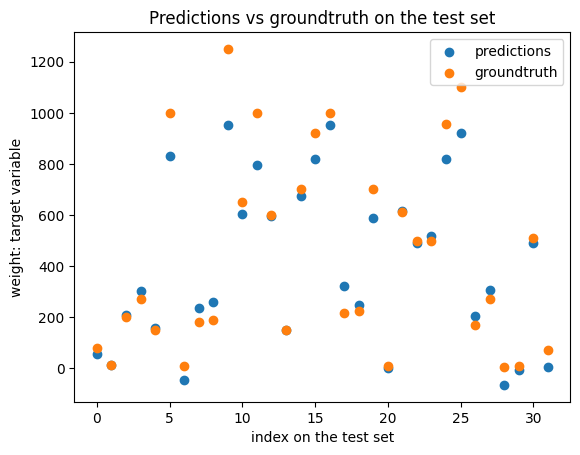

In [64]:
## PLOT OF THE PREDICTIONS VS THE GROUNDTRUTH ON THE DATASET

t = np.arange(0, len(X_test))
fig, ax = plt.subplots()

plt.scatter(t, predictions_test)
plt.scatter(t, y_test)

## add a title
plt.title("Predictions vs groundtruth on the test set")

## add labels to the axis

plt.xlabel("index on the test set")
plt.ylabel("weight: target variable")

plt.legend(["predictions", "groundtruth"])

plt.show()

In [65]:
X_train

array([[-1.20548053, -1.06273398, -1.10441696, ..., -0.41943525,
        -0.27617239, -0.15554275],
       [ 2.03707663, -0.25944123,  0.27042307, ..., -0.41943525,
        -0.27617239, -0.15554275],
       [-0.18212029,  0.89187139,  0.16361254, ..., -0.41943525,
        -0.27617239, -0.15554275],
       ...,
       [ 0.45029334,  1.53875352,  0.45517641, ..., -0.41943525,
        -0.27617239, -0.15554275],
       [-0.5730669 , -0.5105016 , -0.49487834, ..., -0.41943525,
        -0.27617239, -0.15554275],
       [-0.0326407 , -0.12612818,  0.43460049, ..., -0.41943525,
        -0.27617239, -0.15554275]])

In [74]:
import numpy as np

import statsmodels.api as sm

X_train_constant = sm.add_constant(X_train)

mod = sm.OLS(y_train, X_train_constant) ## y = b0 + b1 X1 + b2 X2 + ...+ bnXn

res = mod.fit()



In [76]:
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     203.8
Date:                Sat, 02 Aug 2025   Prob (F-statistic):           3.93e-67
Time:                        10:49:00   Log-Likelihood:                -723.96
No. Observations:                 127   AIC:                             1468.
Df Residuals:                     117   BIC:                             1496.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        357.4427      6.689     53.440      0.0

In [ ]:
### Refactor the project

## 1. clean the data: missing nans, outlier analysis
## 2. Ablation study: is the impact study of making changes in your pipeline on your final model
## 3. X,y explanatory variables
## 4. dummification of categoricl variables if they exist
## 5. train test split
## 6. Standardize the data
## 7. Fit the model
## 8. Evaluating the model

In [ ]:
## in many situations we have to do a/b testing or clinical trial to check linear responses of one feature regarding the dataset.
## so the strategy is that we pick the features with p values less than 0.05 and so on.
## to do systematically pls use adjusted p value strategies such as Boneffroni (advanced remark)